TASK


In [10]:
!pip install -q sentence-transformers scikit-learn matplotlib

In [11]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [20]:
sentence = "I love learning Artificial Intelligence"

embedding = model.encode(sentence)

print("Embedding shape:", embedding.shape)
print("First 10 values:", embedding[:10])

Embedding shape: (384,)
First 10 values: [ 0.00171317 -0.08211406  0.05430845  0.00576471  0.04894556 -0.05850276
  0.05949197  0.03248557  0.06311154  0.04958308]


In [21]:
sentences = [
    "I love learning Artificial Intelligence",
    "Machine learning is very interesting",
    "I enjoy playing football"
]

embeddings = model.encode(sentences)

print("Number of sentences:", len(embeddings))
print("Embedding shape:", embeddings.shape)

Number of sentences: 3
Embedding shape: (3, 384)


In [23]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print(similarity)

[[0.9999999  0.63010097 0.41194108]
 [0.63010097 1.0000001  0.13025953]
 [0.41194108 0.13025953 1.0000001 ]]


In [24]:
print("Similarity (Sentence 1 vs 2):", similarity[0][1])

Similarity (Sentence 1 vs 2): 0.63010097


In [25]:
print("Similarity (Sentence 1 vs 3):", similarity[0][2])

Similarity (Sentence 1 vs 3): 0.41194108


In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

print("Original shape:", embeddings.shape)
print("New shape:", embeddings_2d.shape)

Original shape: (3, 384)
New shape: (3, 2)


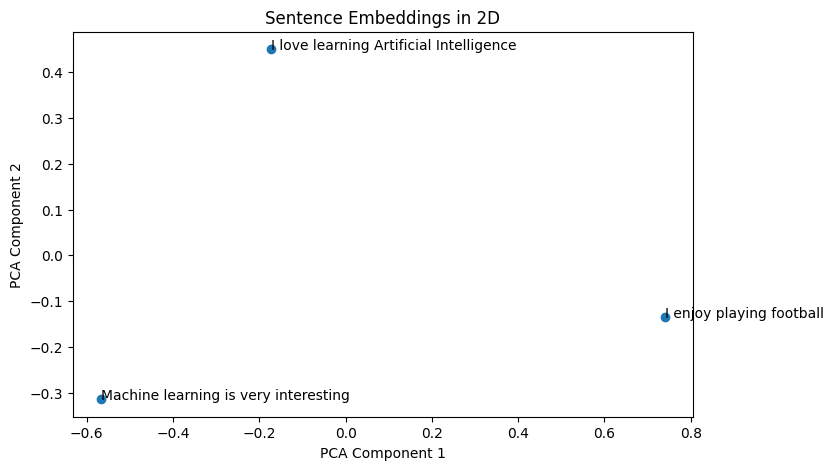

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])

for i, sentence in enumerate(sentences):
    plt.annotate(sentence, (embeddings_2d[i, 0], embeddings_2d[i, 1]))

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Sentence Embeddings in 2D")
plt.show()

In [28]:
documents = [
    "Python is a popular programming language for AI.",
    "The weather today is sunny and warm.",
    "Machine learning models learn patterns from data.",
    "I enjoy playing football on weekends.",
    "Deep learning uses neural networks with many layers.",
    "Paris is the capital city of France."
]

doc_embeddings = model.encode(documents)

print("Number of documents:", len(documents))
print("Embedding shape:", doc_embeddings.shape)

Number of documents: 6
Embedding shape: (6, 384)


In [29]:
def semantic_search(query, documents, doc_embeddings):
    query_embedding = model.encode([query])

    similarities = cosine_similarity(
        query_embedding,
        doc_embeddings
    )[0]

    results = sorted(
        zip(documents, similarities),
        key=lambda x: x[1],
        reverse=True
    )

    for doc, score in results:
        print(f"{score:.4f}  →  {doc}")

In [30]:
semantic_search(
    "Tell me about AI and neural networks",
    documents,
    doc_embeddings
)

0.5342  →  Deep learning uses neural networks with many layers.
0.5242  →  Python is a popular programming language for AI.
0.3589  →  Machine learning models learn patterns from data.
0.1105  →  Paris is the capital city of France.
-0.0185  →  The weather today is sunny and warm.
-0.0190  →  I enjoy playing football on weekends.


In [31]:
semantic_search(
    "What is the capital of France?",
    documents,
    doc_embeddings
)

0.8243  →  Paris is the capital city of France.
0.1020  →  Python is a popular programming language for AI.
0.0666  →  Deep learning uses neural networks with many layers.
0.0645  →  The weather today is sunny and warm.
0.0395  →  Machine learning models learn patterns from data.
-0.0004  →  I enjoy playing football on weekends.
